# Testing the i.i.d.-Domains Assumption in EQRM

The EQRM algorithm assumes training domains are drawn **i.i.d.** from a meta-distribution $P_\mathcal{E}$.
The paper notes:

> *"Future work could look to relax the i.i.d.-domains assumption by leveraging knowledge of domain dependencies (e.g. time)."*

This notebook tests **when and how EQRM breaks down** by making domains evolve sequentially over "time".

### Experiments
- **Experiment A — Gradual Variance Shift**: Noise variance $\sigma_{\text{effect}}$ follows an AR(1) process across domains.
- **Experiment B — Gradual Mean Shift**: A location shift $z(t)$ is applied to $X_2$, increasing linearly across domains.

### No source code modifications
We reuse the `Example2` SCM by manually constructing the `dataset.envs` dictionary with time-correlated values.

---
## 1. Setup & Configuration

In [1]:
# Global plotting configuration for high contrast and accessibility
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
    "lines.linewidth": 2,
    "lines.markersize": 8
})
print("Global plotting style set.")

Global plotting style set.


In [2]:
import sys
import os
import copy

# Make sure we can import from the LinearRegression directory
LR_DIR = os.path.dirname(os.path.abspath('__file__'))  # notebook dir = LinearRegression/
if LR_DIR not in sys.path:
    sys.path.insert(0, LR_DIR)

import torch
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

import datasets
import algorithms
import utils
import plotting

# Override LaTeX rendering set by plotting.py (requires missing system LaTeX packages)
plt.rc("text", usetex=False)
plt.rcParams["mathtext.fontset"] = "dejavuserif"
from distributions import *

%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"Imports successful from: {LR_DIR}")

PyTorch version: 2.11.0+cu130
Imports successful from: /home/samuel/Documents/udem/masters/session2/ift6168/IFT6168/LinearRegression


In [3]:
# ─── Experiment configuration ───────────────────────────────────
SEED = 0
N_ENVS = 10000           # number of training environments
N_SAMPLES = 5000       # samples per environment
N_ITERATIONS = 1000     # SGD iterations
DIM_INV = 1             # invariant (causal-ish) feature dimension
DIM_SPU = 1             # non-causal (spurious) feature dimension
IN_FEATURES = DIM_INV + DIM_SPU

# EQRM alpha values
ALPHA_VALUES = [0.5, 0.75, 0.9, 0.99]

# Experiment A: AR(1) autocorrelation strengths
RHO_VALUES = [0.0, 0.25, 0.5, 0.75, 0.9, 0.99]

# Experiment B: Mean shift magnitudes
ZMAX_VALUES = [0.0, 0.5, 1.0, 3.0, 5.0]

# Output directory for figures
FIGS_DIR = "figs_iid_violation/"
os.makedirs(FIGS_DIR, exist_ok=True)

print(f"Config: {N_ENVS} envs, {N_SAMPLES} samples, {N_ITERATIONS} iters")
print(f"Experiment A — ρ values: {RHO_VALUES}")
print(f"Experiment B — z_max values: {ZMAX_VALUES}")
print(f"EQRM α values: {ALPHA_VALUES}")

Config: 10000 envs, 5000 samples, 1000 iters
Experiment A — ρ values: [0.0, 0.25, 0.5, 0.75, 0.9, 0.99]
Experiment B — z_max values: [0.0, 0.5, 1.0, 3.0, 5.0]
EQRM α values: [0.5, 0.75, 0.9, 0.99]


In [4]:
class ComplexSCMDataset(datasets.Example2):
    def sample(self, n=1000, env="E0", split="train"):
        if "q=" in env:
            # Specified quantile under p_env, i.e. P(S <= sdv) = q
            q = torch.tensor(float(env[env.index("=") + 1:]), dtype=torch.float64)
            sdv = self.p_env.icdf(q)
        elif "test" in env:
            # Random sample from domain distribution
            sdv = self.p_env.sample()
        else:
            # Use existing fixed environment
            sdv = self.envs[env]

        # Root variable X
        X = torch.randn(n, 1)
        
        # Causal feature X1
        x1 = X + torch.randn(n, 1) * 0.1
        
        # Target Y
        y = x1 + torch.randn(n, 1) * self.y_sdv
        
        # Spurious feature X2 (descendant of Y)
        x2 = y + torch.randn(n, 1) * sdv

        if "E" in env and split == "test":
            # Shuffle the spurious feature to break its correlation with Y
            x2 = x2[torch.randperm(len(x2))]

        # Model gets X1 and X2
        inputs = torch.cat((x1, x2), -1)
        outputs = y.sum(1, keepdim=True)

        if "q=" in env:
            return inputs, outputs, sdv
        else:
            return inputs, outputs
print("ComplexSCMDataset (2-variable) defined.")

ComplexSCMDataset (2-variable) defined.


---
## 2. Helper: AR(1) Variance Sequence Generator

Generate a sequence of noise standard deviations $\sigma_{\text{effect}}(t)$ where consecutive domains are correlated:

$$\log \sigma(t) = \rho \cdot \log \sigma(t-1) + \sqrt{1 - \rho^2} \cdot \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \tau^2)$$

The AR(1) parameterization ensures the **marginal distribution** of $\log \sigma$ is $\mathcal{N}(0, \tau^2)$ regardless of $\rho$,
so only the *independence* changes, not the distributional shape.

/tmp/ipykernel_2063316/4211520098.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


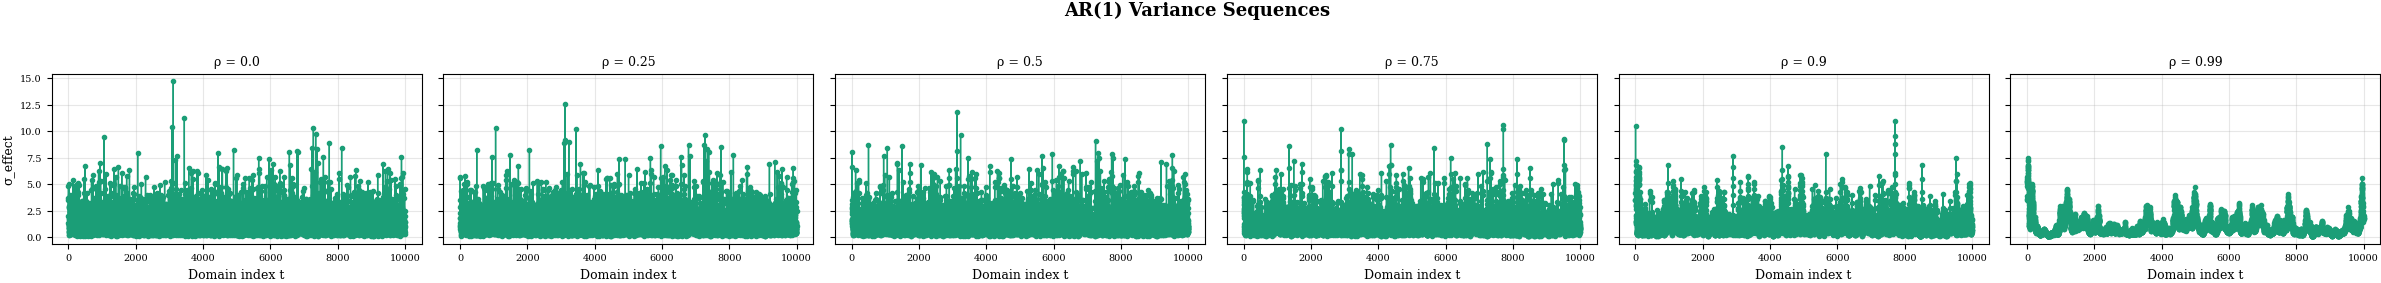


Sample statistics (should have similar mean/std regardless of ρ):
  ρ=0.00: mean(σ)=1.364, std(σ)=1.049
  ρ=0.25: mean(σ)=1.396, std(σ)=1.115
  ρ=0.50: mean(σ)=1.451, std(σ)=1.246
  ρ=0.75: mean(σ)=1.575, std(σ)=1.432
  ρ=0.90: mean(σ)=1.933, std(σ)=1.808
  ρ=0.99: mean(σ)=3.178, std(σ)=1.698


In [5]:
def generate_ar1_variances(n_envs, rho, mu=0.0, tau=math.sqrt(0.5), seed=None):
    """
    Generate a sequence of noise stddevs via an AR(1) process in log-space.
    
    Parameters:
        n_envs: number of environments (time steps)
        rho: autocorrelation coefficient (0 = i.i.d., 1 = deterministic)
        mu: mean of log(sigma) (matches LogNormal(0, sqrt(0.5)) when mu=0)
        tau: std of the innovation noise (matches LogNormal(0, sqrt(0.5)) when tau=sqrt(0.5))
        seed: random seed for reproducibility
    
    Returns:
        list of sigma values (noise stddevs), one per environment
    """
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random.RandomState()
    
    log_sigmas = np.zeros(n_envs)
    
    # Initialize from the stationary distribution
    log_sigmas[0] = mu + tau * rng.randn()
    
    # Generate AR(1) sequence
    innovation_scale = math.sqrt(1 - rho**2) * tau if abs(rho) < 1.0 else 0.0
    for t in range(1, n_envs):
        log_sigmas[t] = mu + rho * (log_sigmas[t-1] - mu) + innovation_scale * rng.randn()
    
    # Exponentiate to get sigma values (ensure positive)
    sigmas = np.exp(log_sigmas)
    
    return sigmas.tolist()


# ─── Verify: visualize AR(1) sequences ─────────────────────────
fig, axes = plt.subplots(1, len(RHO_VALUES), figsize=(4 * len(RHO_VALUES), 3), sharey=True)
for idx, rho in enumerate(RHO_VALUES):
    sigmas = generate_ar1_variances(N_ENVS, rho, seed=SEED)
    axes[idx].plot(sigmas, 'o-', markersize=3, linewidth=1, color='#1B9E77')
    axes[idx].set_title(f'ρ = {rho}')
    axes[idx].set_xlabel('Domain index t')
    if idx == 0:
        axes[idx].set_ylabel('σ_effect')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('AR(1) Variance Sequences', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'ar1_sequences.pdf'))
plt.show()

print("\nSample statistics (should have similar mean/std regardless of ρ):")
for rho in RHO_VALUES:
    sigmas = generate_ar1_variances(200, rho, seed=SEED)
    print(f"  ρ={rho:.2f}: mean(σ)={np.mean(sigmas):.3f}, std(σ)={np.std(sigmas):.3f}")

---
## 3. Helper: Build Environments with Custom Variances

We create a standard `Example2` dataset and then **overwrite `dataset.envs`** with our custom time-dependent variance sequence.

In [6]:
def create_dataset_with_custom_variances(sigmas, dim_inv=1, dim_spu=1):
    """
    Create an Example2 dataset but replace the environment variances with a custom sequence.
    
    We instantiate Example2 normally (so wxy, wyz, p_env etc. are set), then overwrite envs.
    """
    n_envs = len(sigmas)
    ds = ComplexSCMDataset(dim_inv=dim_inv, dim_spu=dim_spu, n_envs=n_envs, verbose=False)
    
    # Overwrite envs with our custom sequence
    ds.envs = {}
    for i, s in enumerate(sigmas):
        ds.envs[f"E{i}"] = s
    
    return ds


def build_envs_from_dataset(dataset, n_samples, train_split="train"):
    """
    Build the train/validation/test environment data from a dataset object.
    Mirrors the logic in the existing experiments notebook.
    """
    envs = {}
    for key_split, split in zip(
        ("train", "validation", "test"),
        (train_split, train_split, "test")
    ):
        envs[key_split] = {"keys": [], "envs": []}
        for env in dataset.envs:
            envs[key_split]["envs"].append(
                dataset.sample(n=n_samples, env=env, split=split)
            )
            envs[key_split]["keys"].append(env)
    return envs


print("Helpers defined.")

Helpers defined.


---
## 4. Helper: Build Environments with Mean Shift

For Experiment B, we add a gradual location shift to $X_2$:

$$X_2 = Y + z(t) + \varepsilon_2, \quad z(t) = z_{\max} \cdot \frac{t}{T-1}$$

Since `Example2.sample()` doesn't support this shift, we **post-process** the sampled data.

/tmp/ipykernel_2063316/2833119747.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


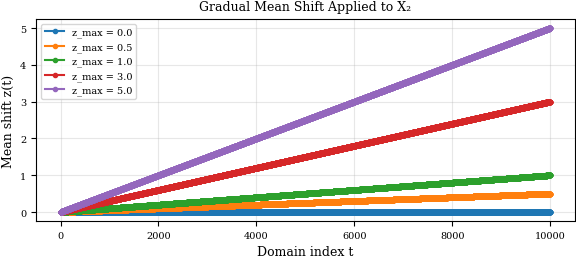

Mean-shift helper defined.


In [7]:
def build_envs_with_mean_shift(dataset, n_samples, z_max, train_split="train"):
    """
    Build environments where X₂ has a gradually increasing mean shift z(t).
    
    The shift z(t) = z_max * t / (T-1) is added to the X₂ component of the inputs.
    """
    n_envs = len(dataset.envs)
    env_names = list(dataset.envs.keys())
    
    envs = {}
    for key_split, split in zip(
        ("train", "validation", "test"),
        (train_split, train_split, "test")
    ):
        envs[key_split] = {"keys": [], "envs": []}
        for t, env in enumerate(env_names):
            inputs, outputs = dataset.sample(n=n_samples, env=env, split=split)
            
            # Apply mean shift to X₂ (the last dim_spu columns)
            if z_max > 0 and n_envs > 1:
                z_t = z_max * t / (n_envs - 1)
                inputs_shifted = inputs.clone()
                inputs_shifted[:, 1] += z_t # X2 is spurious
                envs[key_split]["envs"].append((inputs_shifted, outputs))
            else:
                envs[key_split]["envs"].append((inputs, outputs))
            
            envs[key_split]["keys"].append(env)
    return envs


# ─── Verify: visualize mean shift across domains ──────────────
fig, ax = plt.subplots(figsize=(6, 3))
for z_max in ZMAX_VALUES:
    shifts = [z_max * t / (N_ENVS - 1) for t in range(N_ENVS)]
    ax.plot(shifts, 'o-', markersize=3, linewidth=1.5, label=f'z_max = {z_max}')

ax.set_xlabel('Domain index t')
ax.set_ylabel('Mean shift z(t)')
ax.set_title('Gradual Mean Shift Applied to X₂')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'mean_shift_sequences.pdf'))
plt.show()

print("Mean-shift helper defined.")

---
## 5. Training & Evaluation Helper

A shared function to train ERM, Oracle, and EQRM (at multiple α), and evaluate per-environment risks.

In [8]:
def run_all_algorithms(envs_regular, envs_oracle, in_features, n_iterations, alpha_values, seed=0):
    """
    Train ERM, Oracle, and EQRM (at each alpha) and return results dict.
    
    Returns:
        results: dict of {model_name: {"avg_risk", "max_risk", "std_risk", "w", "per_env_risks"}}
    """
    results = {}
    
    # ─── ERM ──────────────────────────────────────────────
    utils.set_seed(seed + 1000)
    erm = algorithms.ERM(in_features, 1, "regression")
    erm.fit(envs_regular, n_iterations)
    risks = [utils.compute_error(erm, *env) for env in envs_regular["validation"]["envs"]]
    w = erm.network.weight.data.flatten().tolist()
    results["ERM"] = {
        "avg_risk": np.mean(risks), "max_risk": np.max(risks), "std_risk": np.std(risks),
        "w": [round(wi, 4) for wi in w], "per_env_risks": risks, "model": erm
    }
    
    # ─── Oracle ───────────────────────────────────────────
    utils.set_seed(seed + 1000)
    oracle = algorithms.ERM(in_features, 1, "regression")
    oracle.fit(envs_oracle, n_iterations)
    risks = [utils.compute_error(oracle, *env) for env in envs_oracle["validation"]["envs"]]
    w = oracle.network.weight.data.flatten().tolist()
    results["Oracle"] = {
        "avg_risk": np.mean(risks), "max_risk": np.max(risks), "std_risk": np.std(risks),
        "w": [round(wi, 4) for wi in w], "per_env_risks": risks, "model": oracle
    }
    # ─── EQRM (multiple alphas) ──────────────────────────
    for alpha in alpha_values:
        name = f"EQRM_a={alpha}"
        utils.set_seed(seed + 1000)
        eqrm = algorithms.EQRM(in_features, 1, "regression")
        eqrm.hparams["alpha"] = alpha
        eqrm.fit(envs_regular, n_iterations)
        risks = [utils.compute_error(eqrm, *env) for env in envs_regular["validation"]["envs"]]
        w = eqrm.network.weight.data.flatten().tolist()
        results[name] = {
            "avg_risk": np.mean(risks), "max_risk": np.max(risks), "std_risk": np.std(risks),
            "w": [round(wi, 4) for wi in w], "per_env_risks": risks, "model": eqrm
        }
    
    return results


print("Training helper defined.")

Training helper defined.


---
## 6. Experiment A — Gradual Variance Shift (AR(1) Process)

For each $\rho \in \{0, 0.5, 0.9, 0.99\}$:
1. Generate AR(1)-correlated $\sigma_{\text{effect}}$ sequence
2. Create dataset with those variances
3. Train ERM, Oracle, and EQRM
4. Evaluate on **the same training environments** (to see how the risk estimator adapts)

In [9]:
print("="*70)
print("EXPERIMENT A: Gradual Variance Shift (AR(1) Process)")
print("="*70)

exp_a_results = {}  # rho -> results dict
exp_a_sigmas = {}   # rho -> sigma sequence (for plotting)

for rho in RHO_VALUES:
    print(f"\n{'─'*50}")
    print(f"ρ = {rho}")
    print(f"{'─'*50}")
    
    # Generate AR(1) variance sequence
    sigmas = generate_ar1_variances(N_ENVS, rho, seed=SEED)
    exp_a_sigmas[rho] = sigmas
    print(f"  σ range: [{min(sigmas):.3f}, {max(sigmas):.3f}], mean={np.mean(sigmas):.3f}")
    
    # Create dataset with custom variances
    utils.set_seed(SEED)
    ds = create_dataset_with_custom_variances(sigmas, DIM_INV, DIM_SPU)
    
    # Build training environments
    envs_r = build_envs_from_dataset(ds, N_SAMPLES, "train")
    envs_o = build_envs_from_dataset(ds, N_SAMPLES, "test")
    
    # Train and evaluate all algorithms
    results = run_all_algorithms(envs_r, envs_o, IN_FEATURES, N_ITERATIONS, ALPHA_VALUES, SEED)
    results['models'] = {name: res['model'] for name, res in results.items() if name != 'models'}
    exp_a_results[rho] = results
    
    # Print summary
    for m_name, m_res in results.items():
        if m_name == 'models': continue
        print(f"  {m_name:15s} | avg={m_res['avg_risk']:.4f} | max={m_res['max_risk']:.4f} "
              f"| β_cause={m_res['w'][0]:.3f} | β_effect={m_res['w'][1]:.3f}")

print("\n✅ Experiment A complete.")

EXPERIMENT A: Gradual Variance Shift (AR(1) Process)

──────────────────────────────────────────────────
ρ = 0.0
──────────────────────────────────────────────────
  σ range: [0.071, 14.705], mean=1.261
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.95
  ERM             | avg=1.1290 | max=42.8972 | β_cause=0.565 | β_effect=0.435
  Oracle          | avg=1.9996 | max=2.1486 | β_cause=1.000 | β_effect=0.000
  EQRM_a=0.5      | avg=1.2370 | max=77.7835 | β_cause=0.409 | β_effect=0.589
  EQRM_a=0.75     | avg=1.1479 | max=31.5150 | β_cause=0.621 | β_effect=0.371
  EQRM_a=0.9      | avg=1.4464 | max=7.9404 | β_cause=0.817 | β_effect=0.172
  EQRM_a=0.99     | avg=1.9043 | max=2.0516 | β_cause=0.967 | β_effect=0.025

──────────────────────────────────────────────────
ρ = 0.25
──────────────────────────────────────────────────
  σ range: [0.076, 12.567], mean=1.256
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.95
  ERM             | avg=1.1234 | max=31.8751 | β_cause=0.562 | β_effect=0.438
  Oracl

---
## 7. Experiment B — Gradual Mean Shift

For each $z_{\max} \in \{0, 1, 3, 5\}$:
1. Create a standard i.i.d. dataset (LogNormal env distribution)
2. Apply gradual mean shift $z(t) = z_{\max} \cdot t / (T-1)$ to $X_2$
3. Train ERM, Oracle, and EQRM
4. Evaluate on the shifted environments

In [10]:
print("="*70)
print("EXPERIMENT B: Gradual Mean Shift")
print("="*70)

exp_b_results = {}  # z_max -> results dict

for z_max in ZMAX_VALUES:
    print(f"\n{'─'*50}")
    print(f"z_max = {z_max}")
    print(f"{'─'*50}")
    
    # Create standard i.i.d. dataset
    utils.set_seed(SEED)
    ds = ComplexSCMDataset(dim_inv=DIM_INV, dim_spu=DIM_SPU, n_envs=N_ENVS, verbose=False)
    
    # Build environments WITH mean shift
    envs_r = build_envs_with_mean_shift(ds, N_SAMPLES, z_max, train_split="train")
    envs_o = build_envs_with_mean_shift(ds, N_SAMPLES, z_max, train_split="test")
    
    # Train and evaluate
    results = run_all_algorithms(envs_r, envs_o, IN_FEATURES, N_ITERATIONS, ALPHA_VALUES, SEED)
    results['models'] = {name: res['model'] for name, res in results.items() if name != 'models'}
    exp_b_results[z_max] = results
    
    # Print summary
    for m_name, m_res in results.items():
        if m_name == 'models': continue
        print(f"  {m_name:15s} | avg={m_res['avg_risk']:.4f} | max={m_res['max_risk']:.4f} "
              f"| β_cause={m_res['w'][0]:.3f} | β_effect={m_res['w'][1]:.3f}")

print("\n✅ Experiment B complete.")

EXPERIMENT B: Gradual Mean Shift

──────────────────────────────────────────────────
z_max = 0.0
──────────────────────────────────────────────────
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.95
  ERM             | avg=1.1532 | max=27.5306 | β_cause=0.576 | β_effect=0.424
  Oracle          | avg=1.9996 | max=2.1486 | β_cause=1.000 | β_effect=0.000
  EQRM_a=0.5      | avg=1.2668 | max=50.3707 | β_cause=0.417 | β_effect=0.578
  EQRM_a=0.75     | avg=1.1700 | max=20.5973 | β_cause=0.632 | β_effect=0.364
  EQRM_a=0.9      | avg=1.8613 | max=2.0757 | β_cause=0.962 | β_effect=0.036
  EQRM_a=0.99     | avg=1.8654 | max=2.0679 | β_cause=0.958 | β_effect=0.035

──────────────────────────────────────────────────
z_max = 0.5
──────────────────────────────────────────────────
Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.95
  ERM             | avg=1.1570 | max=27.3001 | β_cause=0.578 | β_effect=0.422
  Oracle          | avg=1.9996 | max=2.1486 | β_cause=1.000 | β_effect=0.000
  EQRM_a=0.5      | a

---
## 8. Visualization — Experiment A: Risk vs. Autocorrelation ρ

In [27]:
table_quantiles_a = {}
ds_eval = ComplexSCMDataset(n_envs=N_ENVS)
qs = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99]

for rho in RHO_VALUES:
    res_rho = exp_a_results[rho]
    models_eval = res_rho.get('models', {n: r['model'] for n, r in res_rho.items() if isinstance(r, dict) and 'model' in r})
    
    key = f'rho={rho}'
    table_quantiles_a[key] = {}
    for name, model in models_eval.items():
        if name == 'models': continue
        table_quantiles_a[key][name] = {}
        for q in qs:
            inputs, outputs, sdv = ds_eval.sample(n=N_SAMPLES, env=f'q={q}')
            risk = utils.compute_error(model, inputs, outputs)
            table_quantiles_a[key][name][f'q={q}_s={round(sdv.item(), 2)}'] = {'mean': risk}



Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.93


Plotting Quantile Performance for Experiment A...


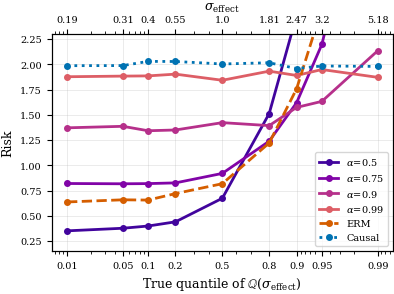

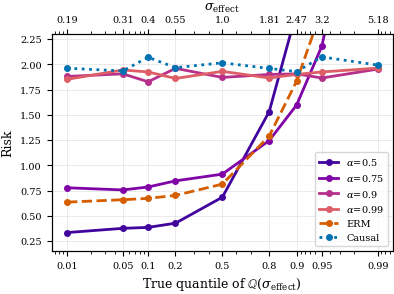

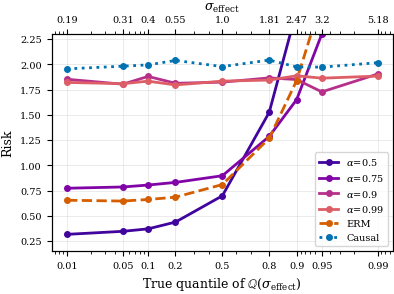

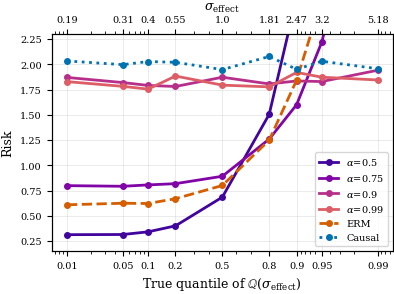

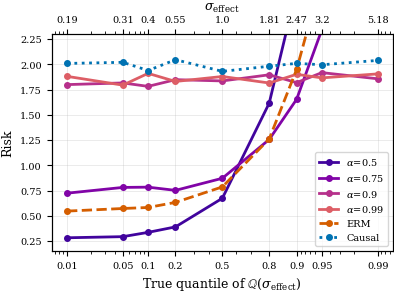

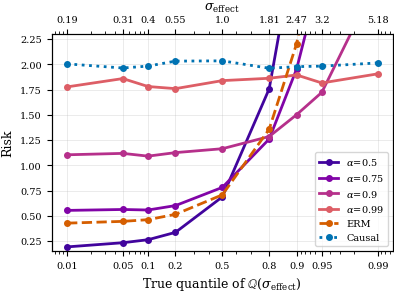

In [13]:
print("Plotting Quantile Performance for Experiment A...")
for rho in RHO_VALUES:
    key = f'rho={rho}'
    table_rho = {key: table_quantiles_a[key]}
    plotting.plot_quantile_performance(table_rho, savedir='figs_iid_violation', fname='exp_a_quantile_perf')
    plt.show()

Model styles updated with premium color palette.


/tmp/ipykernel_2063316/2038699524.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


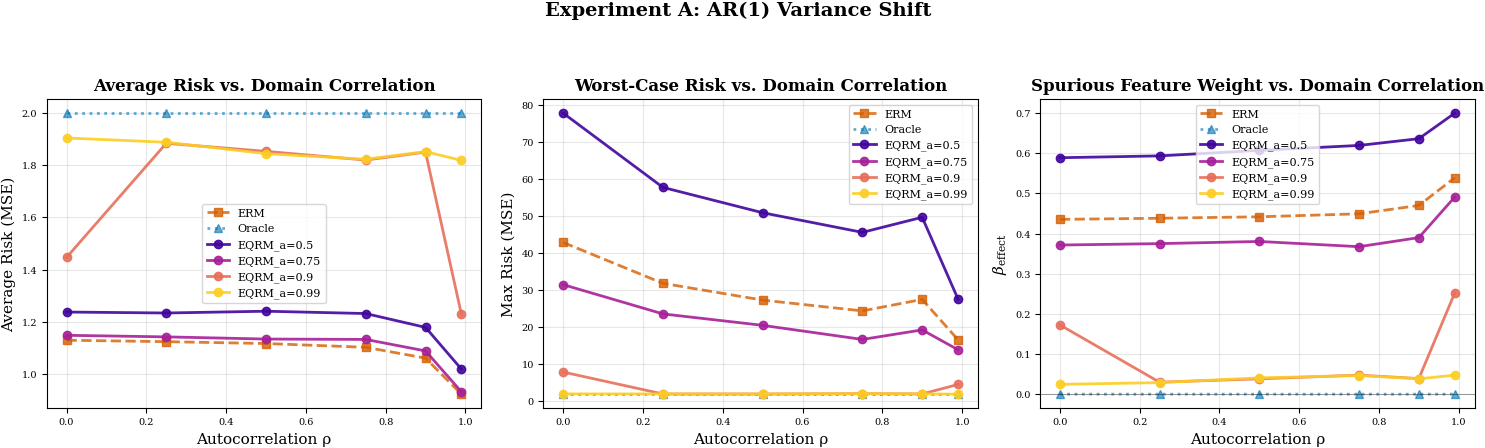

In [14]:
model_names = [n for n in exp_a_results[RHO_VALUES[0]].keys() if n != "models"]

# Premium Color Palette
COLORS = {
    'ERM': '#D55E00',     # Vermillion (colorblind-safe)
    'Oracle': '#0072B2',  # Blue (colorblind-safe)
    'EQRM_gradient': plt.cm.plasma(np.linspace(0.1, 0.9, len(ALPHA_VALUES)))
}

model_styles = {
    "ERM": {"color": COLORS['ERM'], "linestyle": "--", "marker": "s", "alpha": 0.8},
    "Oracle": {"color": COLORS['Oracle'], "linestyle": ":", "marker": "^", "alpha": 0.6},
}

for i, alpha in enumerate(ALPHA_VALUES):
    name = f"EQRM_a={alpha}"
    model_styles[name] = {
        "color": COLORS['EQRM_gradient'][i], 
        "linestyle": "-", 
        "marker": "o",
        "alpha": 0.9
    }

print("Model styles updated with premium color palette.")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ─── 8a. Average Risk vs ρ ─────────────────────────────
ax = axes[0]
for m_name in model_names:
    avg_risks = [exp_a_results[rho][m_name]["avg_risk"] for rho in RHO_VALUES]
    style = model_styles[m_name]
    ax.plot(RHO_VALUES, avg_risks, label=m_name, **style, markersize=6, linewidth=2)

ax.set_xlabel('Autocorrelation ρ', fontsize=11)
ax.set_ylabel('Average Risk (MSE)', fontsize=11)
ax.set_title('Average Risk vs. Domain Correlation', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 8b. Max Risk vs ρ ─────────────────────────────────
ax = axes[1]
for m_name in model_names:
    max_risks = [exp_a_results[rho][m_name]["max_risk"] for rho in RHO_VALUES]
    style = model_styles[m_name]
    ax.plot(RHO_VALUES, max_risks, label=m_name, **style, markersize=6, linewidth=2)

ax.set_xlabel('Autocorrelation ρ', fontsize=11)
ax.set_ylabel('Max Risk (MSE)', fontsize=11)
ax.set_title('Worst-Case Risk vs. Domain Correlation', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 8c. β_effect vs ρ ────────────────────────────────
ax = axes[2]
for m_name in model_names:
    beta_effects = [exp_a_results[rho][m_name]["w"][1] for rho in RHO_VALUES]
    style = model_styles[m_name]
    ax.plot(RHO_VALUES, beta_effects, label=m_name, **style, markersize=6, linewidth=2)

ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Autocorrelation ρ', fontsize=11)
ax.set_ylabel(r'$\beta_{\mathrm{effect}}$', fontsize=11)
ax.set_title('Spurious Feature Weight vs. Domain Correlation', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Experiment A: AR(1) Variance Shift', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'exp_a_risk_vs_rho.pdf'), bbox_inches='tight')
plt.show()

### 8.1. Risk Distributions per $\rho$

These plots show how the distribution of risk across domains changes as the autocorrelation $\rho$ increases. High $\rho$ means the domains are more "clustered" in time, which can lead to higher worst-case risks for non-robust models.

/tmp/ipykernel_2063316/1017496144.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


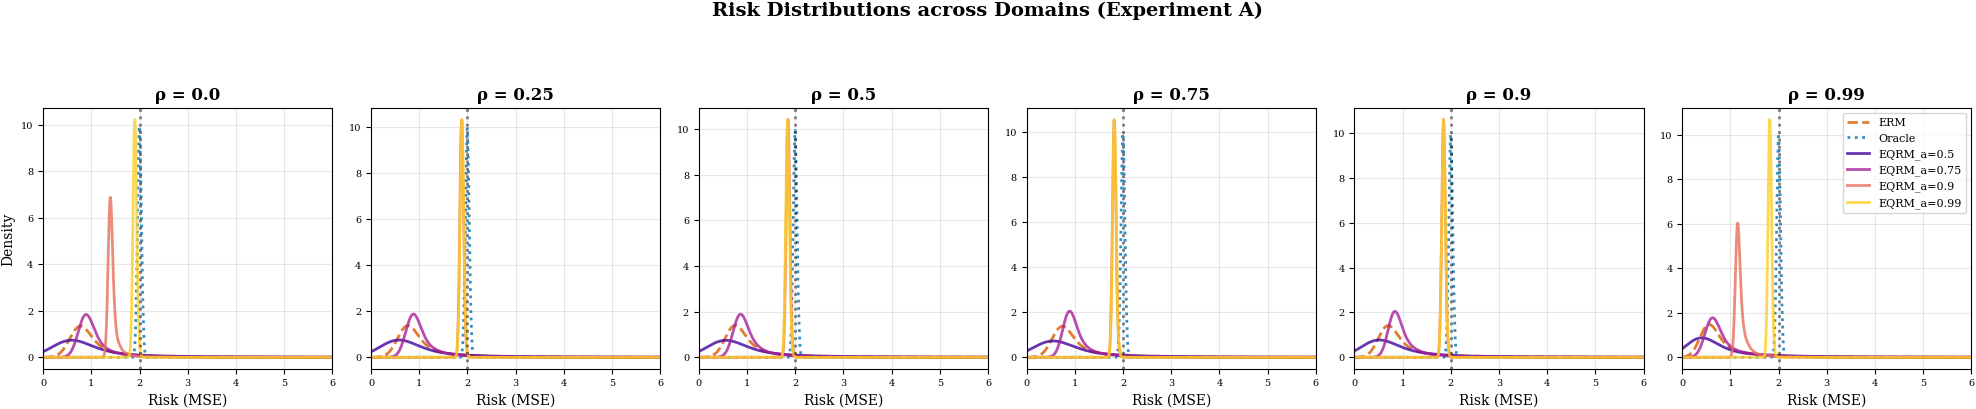

In [15]:
fig, axes = plt.subplots(1, len(RHO_VALUES), figsize=(20, 4), sharey=False)

xlim_max = 6  # Focus on the majority of the density
xs = np.linspace(0, xlim_max, 1000)

for i, rho in enumerate(RHO_VALUES):
    ax = axes[i]
    results_rho = exp_a_results[rho]
    
    for m_name in model_names:
        per_env_risks = results_rho[m_name].get("per_env_risks")
        if per_env_risks is None: continue
        
        style = model_styles[m_name]
        
        # Build KDE using the utility function
        kde = utils.KernelDensityEstimator(torch.tensor(per_env_risks))
        with torch.no_grad():
            p_xs = kde(torch.from_numpy(xs)).numpy()
        
        ax.plot(xs, p_xs, label=m_name, color=style["color"], 
                linestyle=style["linestyle"], linewidth=2, alpha=0.8)

    ax.set_title(f'ρ = {rho}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk (MSE)', fontsize=10)
    if i == 0:
        ax.set_ylabel('Density', fontsize=10)
    ax.set_xlim(0, xlim_max)
    ax.grid(True, alpha=0.3)
    
    # Add vertical line for Oracle average risk if possible
    oracle_avg = results_rho["Oracle"]["avg_risk"]
    ax.axvline(oracle_avg, color='black', linestyle=':', alpha=0.5)

axes[-1].legend(fontsize=8, loc='upper right')
plt.suptitle('Risk Distributions across Domains (Experiment A)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'exp_a_risk_dist_rho.pdf'), bbox_inches='tight')
plt.show()

---
## 9. Visualization — Experiment B: Risk vs. Mean Shift $z_{\max}$

In [26]:
table_quantiles_b = {}
ds_eval = ComplexSCMDataset(n_envs=N_ENVS)
qs = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99]

for z_max in ZMAX_VALUES:
    res_dict = exp_b_results.get(z_max, {})
    models_eval = res_dict.get('models', {n: r['model'] for n, r in res_dict.items() if isinstance(r, dict) and 'model' in r})
    
    key = f'z_max={z_max}'
    table_quantiles_b[key] = {}
    for name, model in models_eval.items():
        if name == 'models': continue
        table_quantiles_b[key][name] = {}
        for q in qs:
            inputs, outputs, sdv = ds_eval.sample(n=N_SAMPLES, env=f'q={q}')
            inputs_shifted = inputs.clone()
            inputs_shifted[:, 1] += z_max
            risk = utils.compute_error(model, inputs_shifted, outputs)
            table_quantiles_b[key][name][f'q={q}_s={round(sdv.item(), 2)}'] = {'mean': risk}



Analytical OLS results
X1:MSE=1.33;	X2:MSE=0.96


Plotting Quantile Performance for Experiment B...


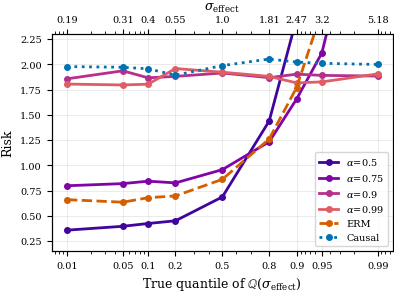

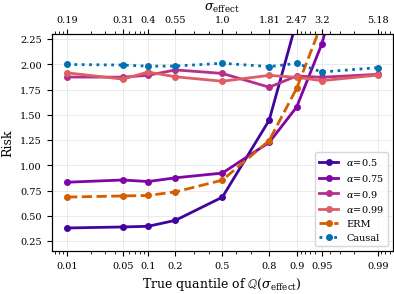

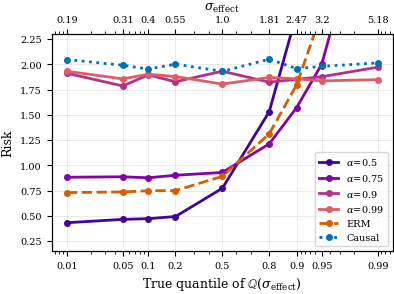

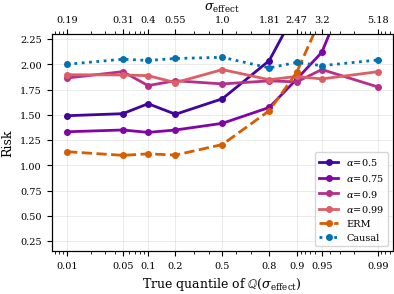

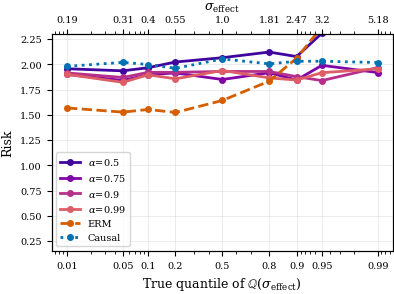

In [18]:
print("Plotting Quantile Performance for Experiment B...")
for z_max in ZMAX_VALUES:
    key = f'z_max={z_max}'
    table_z = {key: table_quantiles_b[key]}
    plotting.plot_quantile_performance(table_z, savedir='figs_iid_violation', fname='exp_b_quantile_perf')
    plt.show()

/tmp/ipykernel_2063316/742562270.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


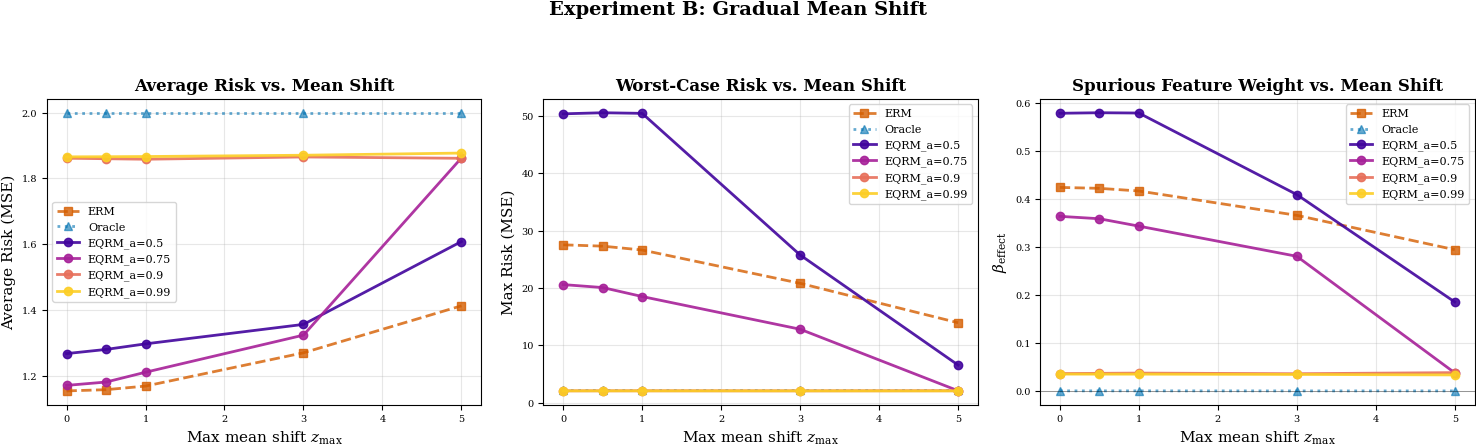

In [19]:
model_names_b = [n for n in exp_b_results[ZMAX_VALUES[0]].keys() if n != "models"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ─── 9a. Average Risk vs z_max ────────────────────────
ax = axes[0]
for m_name in model_names_b:
    avg_risks = [exp_b_results[z][m_name]["avg_risk"] for z in ZMAX_VALUES]
    style = model_styles[m_name]
    ax.plot(ZMAX_VALUES, avg_risks, label=m_name, **style, markersize=6, linewidth=2)

ax.set_xlabel(r'Max mean shift $z_{\max}$', fontsize=11)
ax.set_ylabel('Average Risk (MSE)', fontsize=11)
ax.set_title('Average Risk vs. Mean Shift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 9b. Max Risk vs z_max ────────────────────────────
ax = axes[1]
for m_name in model_names_b:
    max_risks = [exp_b_results[z][m_name]["max_risk"] for z in ZMAX_VALUES]
    style = model_styles[m_name]
    ax.plot(ZMAX_VALUES, max_risks, label=m_name, **style, markersize=6, linewidth=2)

ax.set_xlabel(r'Max mean shift $z_{\max}$', fontsize=11)
ax.set_ylabel('Max Risk (MSE)', fontsize=11)
ax.set_title('Worst-Case Risk vs. Mean Shift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 9c. β_effect vs z_max ───────────────────────────
ax = axes[2]
for m_name in model_names_b:
    beta_effects = [exp_b_results[z][m_name]["w"][1] for z in ZMAX_VALUES]
    style = model_styles[m_name]
    ax.plot(ZMAX_VALUES, beta_effects, label=m_name, **style, markersize=6, linewidth=2)

ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
ax.set_xlabel(r'Max mean shift $z_{\max}$', fontsize=11)
ax.set_ylabel(r'$\beta_{\mathrm{effect}}$', fontsize=11)
ax.set_title('Spurious Feature Weight vs. Mean Shift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Experiment B: Gradual Mean Shift', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'exp_b_risk_vs_zmax.pdf'), bbox_inches='tight')
plt.show()

### 9.1. Risk Distributions per $z_{\max}$

These plots show how the distribution of risk across domains changes as the mean shift magnitude $z_{\max}$ increases. Since $z(t)$ is a spurious feature shift, robust models (EQRM with high $\alpha$) should ignore it, maintaining a consistent low-risk distribution regardless of $z_{\max}$.

/tmp/ipykernel_2063316/794527893.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


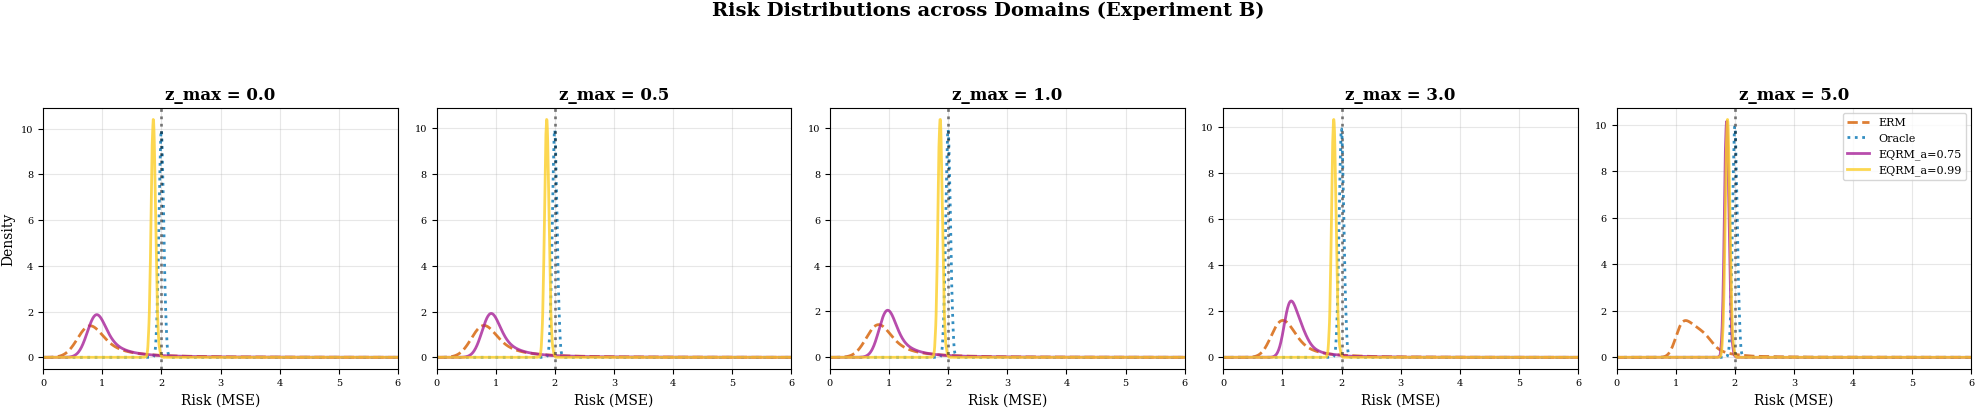

In [20]:
fig, axes = plt.subplots(1, len(ZMAX_VALUES), figsize=(20, 4), sharey=False)

xlim_max = 6  # Focus on the majority of the density
xs = np.linspace(0, xlim_max, 1000)

target_models = ["ERM", "Oracle", "EQRM_a=0.75", "EQRM_a=0.99"]

for i, z_max in enumerate(ZMAX_VALUES):
    ax = axes[i]
    results_z = exp_b_results[z_max]
    
    for m_name in model_names:
        if m_name not in target_models:
            continue
        per_env_risks = results_z[m_name].get("per_env_risks")
        if per_env_risks is None: continue
        
        style = model_styles[m_name]
        
        # Build KDE using the utility function
        kde = utils.KernelDensityEstimator(torch.tensor(per_env_risks))
        with torch.no_grad():
            p_xs = kde(torch.from_numpy(xs)).numpy()
        
        ax.plot(xs, p_xs, label=m_name, color=style["color"], 
                linestyle=style["linestyle"], linewidth=2, alpha=0.8)

    ax.set_title(f'z_max = {z_max}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk (MSE)', fontsize=10)
    if i == 0:
        ax.set_ylabel('Density', fontsize=10)
    ax.set_xlim(0, xlim_max)
    ax.grid(True, alpha=0.3)
    
    # Add vertical line for Oracle average risk if possible
    oracle_avg = results_z["Oracle"]["avg_risk"]
    ax.axvline(oracle_avg, color='black', linestyle=':', alpha=0.5)

axes[-1].legend(fontsize=8, loc='upper right')
plt.suptitle('Risk Distributions across Domains (Experiment B)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'exp_b_risk_dist_zmax.pdf'), bbox_inches='tight')
plt.show()

---
## 10. Visualization — Per-Domain Risk Trajectories

Visualize how per-environment risk evolves across the domain sequence for each algorithm.
In the i.i.d. case, risks should look random; under strong correlation, we expect structure.

/tmp/ipykernel_2063316/1664162483.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


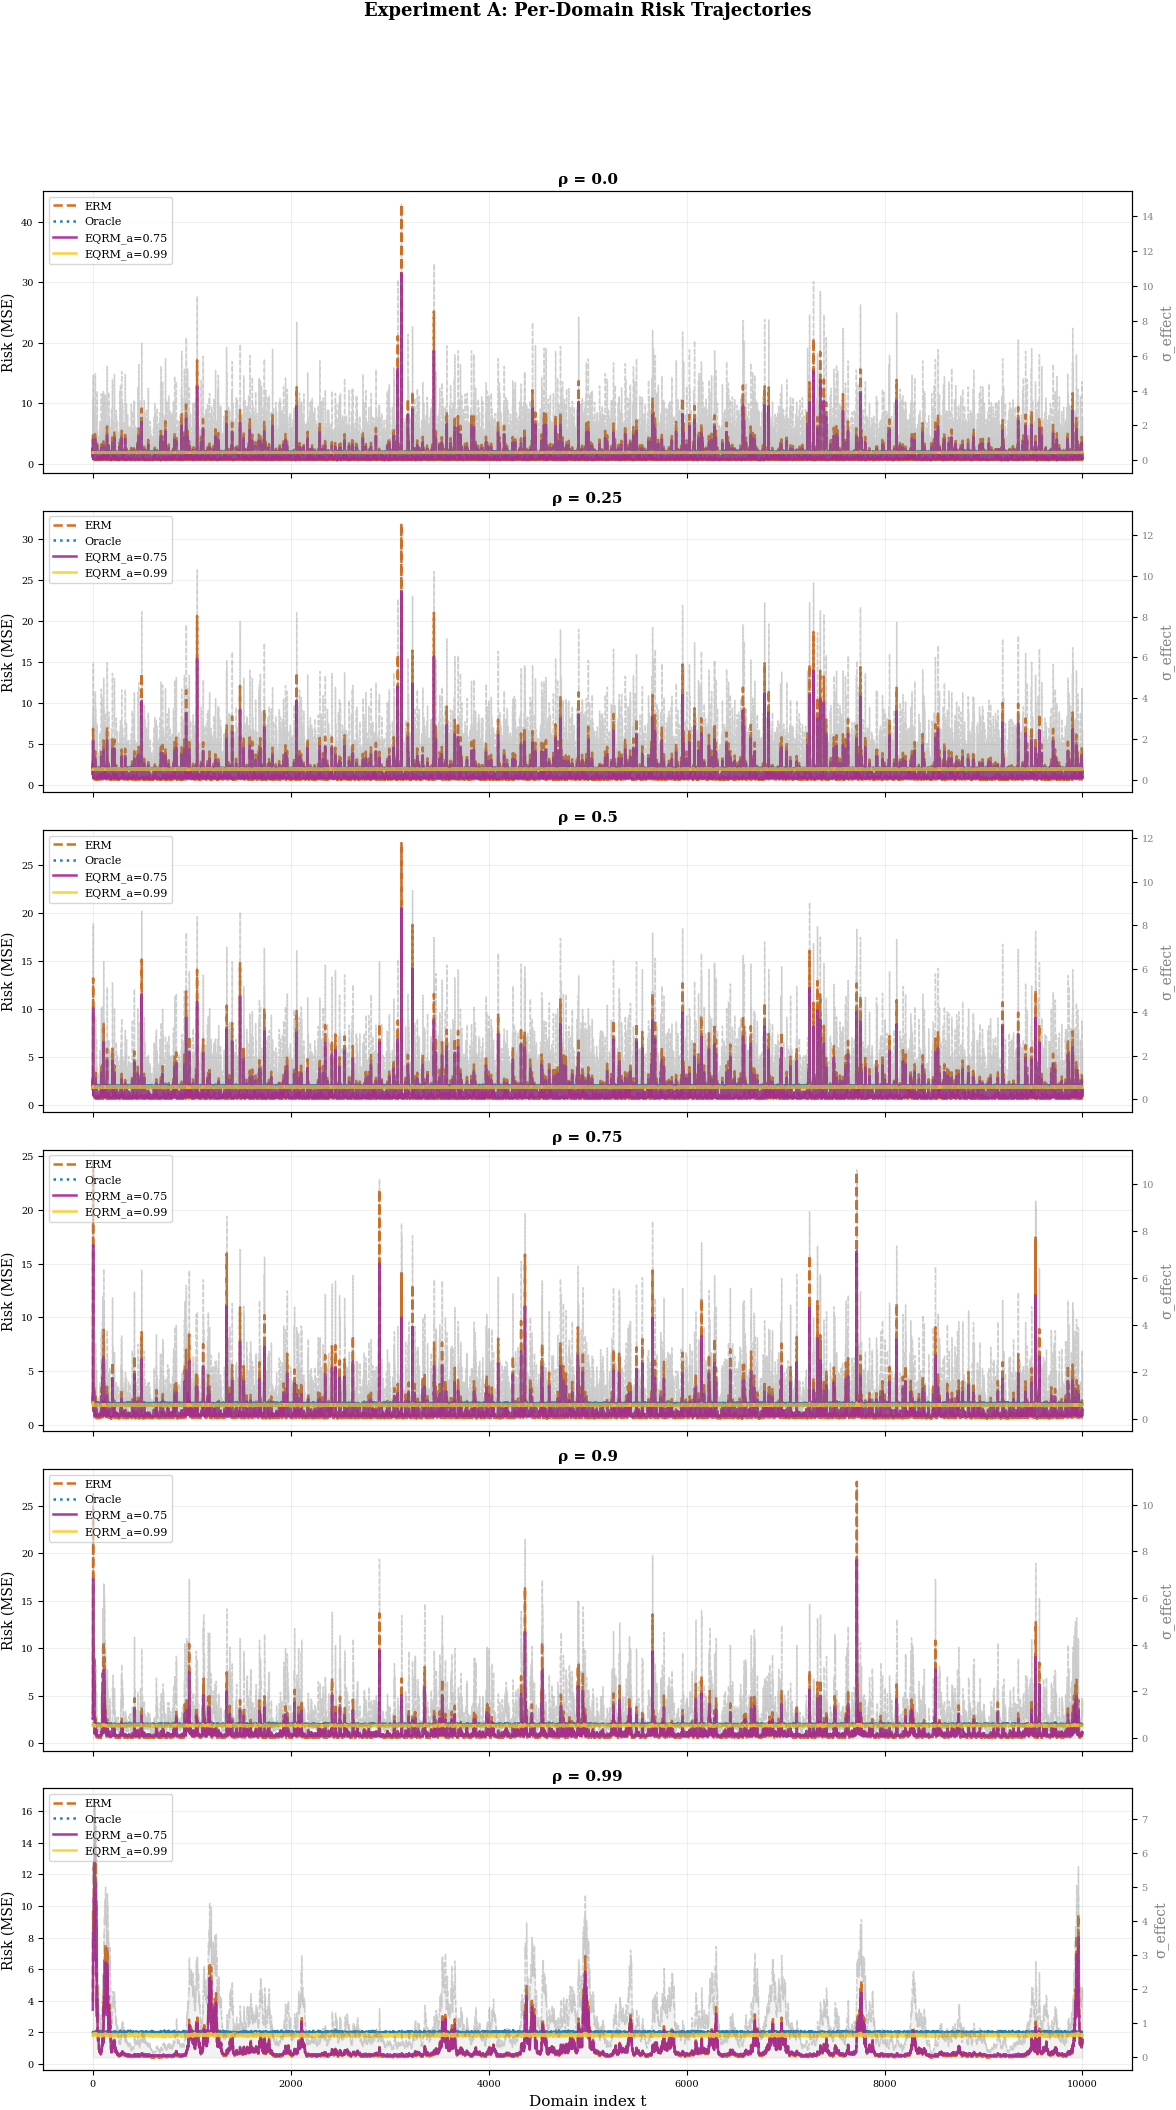

In [21]:
# ─── Experiment A: Per-domain risks for selected ρ values ────
rho_to_plot = RHO_VALUES
fig, axes = plt.subplots(len(rho_to_plot), 1, figsize=(12, 3.5 * len(rho_to_plot)), sharex=True)

for idx, rho in enumerate(rho_to_plot):
    ax = axes[idx]
    
    # Plot sigma sequence on twin axis (Switched to grey for clarity)
    ax2 = ax.twinx()
    sigmas = exp_a_sigmas[rho]
    ax2.fill_between(range(N_ENVS), sigmas, alpha=0.1, color='grey', label='σ_effect')
    ax2.plot(sigmas, color='grey', alpha=0.3, linewidth=1, linestyle='--')
    ax2.set_ylabel('σ_effect', color='grey', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='grey')
    
    # Plot only target models: ERM, Oracle, a=0.75, a=0.99
    target_models = ["ERM", "Oracle", "EQRM_a=0.75", "EQRM_a=0.99"]
    for m_name in target_models:
        if m_name not in model_names: continue
        risks = exp_a_results[rho][m_name]["per_env_risks"]
        style = model_styles[m_name]
        ax.plot(risks, label=m_name, color=style["color"], linestyle=style["linestyle"],
                linewidth=1.8, alpha=0.9)
    
    ax.set_ylabel('Risk (MSE)', fontsize=10)
    ax.set_title(f'ρ = {rho}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.8)

axes[-1].set_xlabel('Domain index t', fontsize=11)
plt.suptitle('Experiment A: Per-Domain Risk Trajectories', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'exp_a_per_domain_risks.pdf'), bbox_inches='tight')
plt.show()


/tmp/ipykernel_2063316/4005523637.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


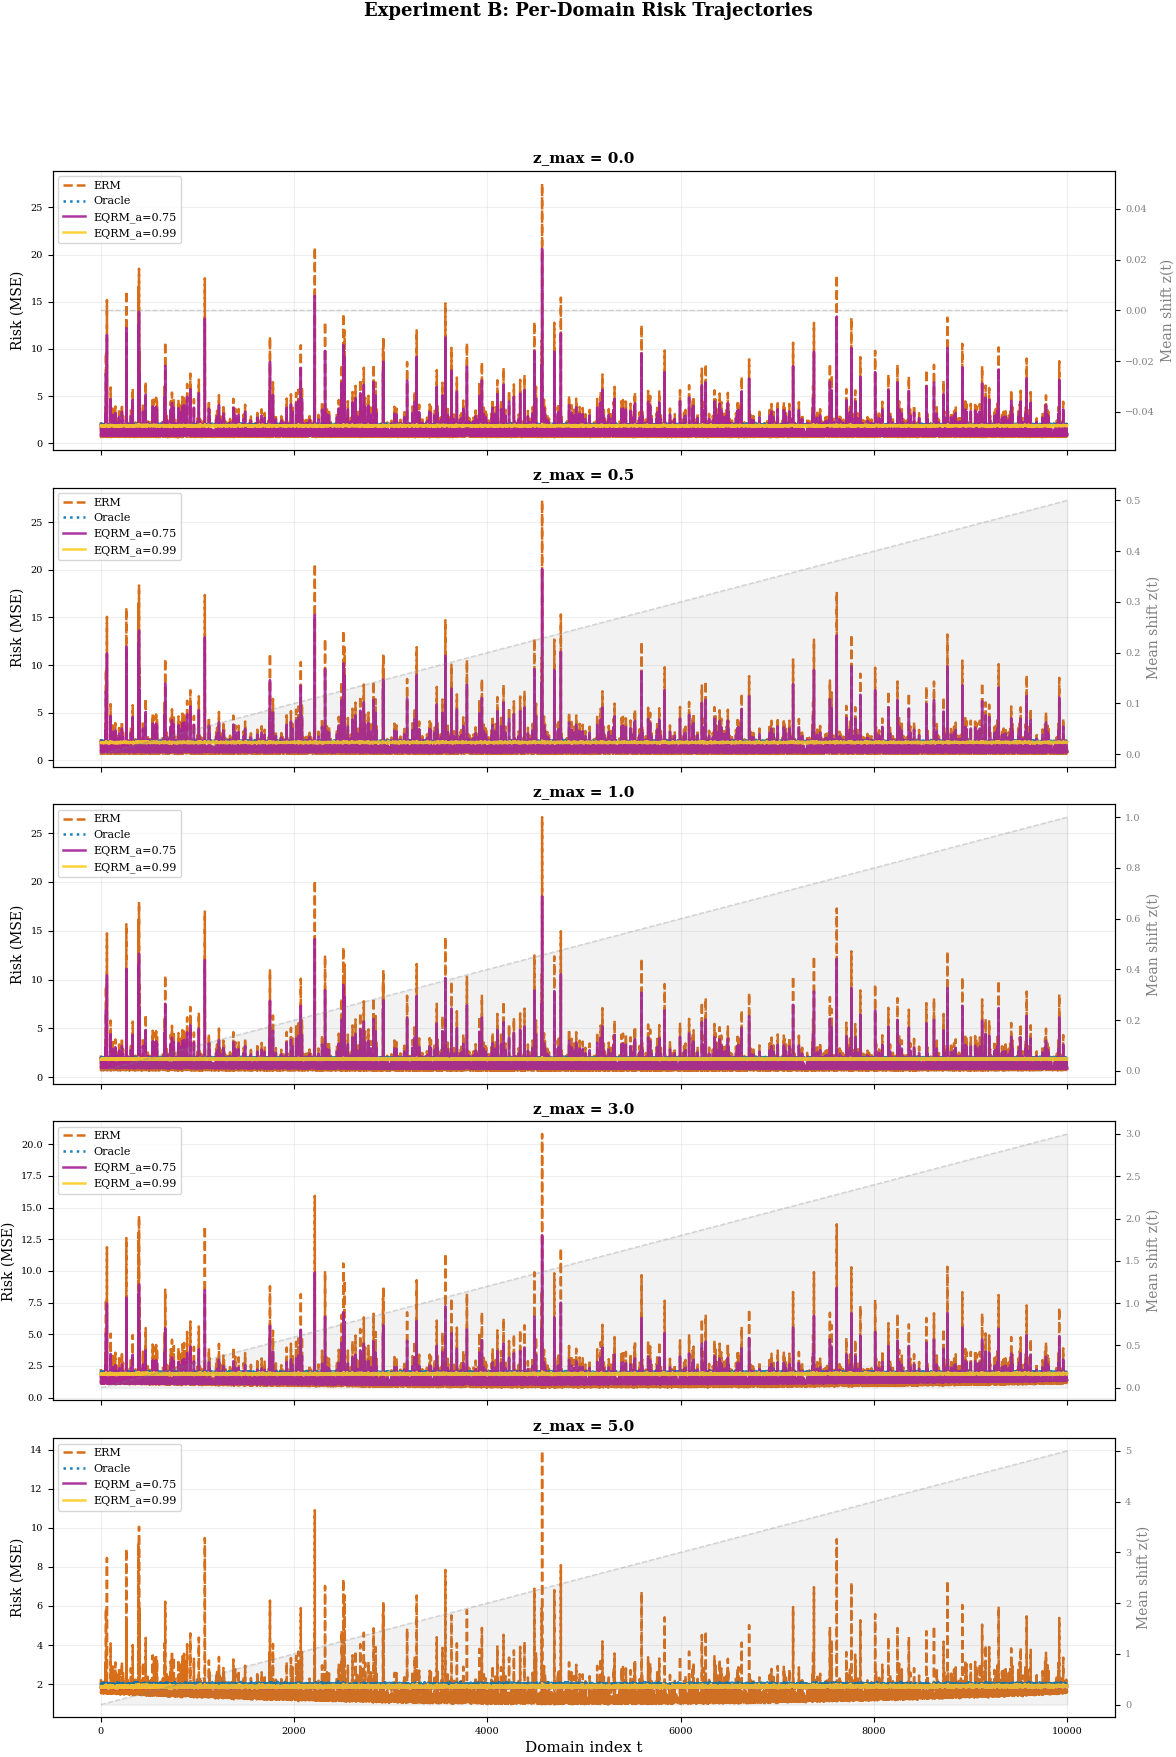

In [22]:
# ─── Experiment B: Per-domain risks for selected z_max values ────
z_max_to_plot = ZMAX_VALUES
fig, axes = plt.subplots(len(z_max_to_plot), 1, figsize=(12, 3.5 * len(z_max_to_plot)), sharex=True)

for idx, z_max in enumerate(z_max_to_plot):
    ax = axes[idx]
    
    # Plot mean shift on twin axis (Switched to grey for clarity)
    ax2 = ax.twinx()
    shifts = [z_max * t / (N_ENVS - 1) for t in range(N_ENVS)]
    ax2.fill_between(range(N_ENVS), shifts, alpha=0.1, color='grey', label='z(t)')
    ax2.plot(shifts, color='grey', alpha=0.3, linewidth=1, linestyle='--')
    ax2.set_ylabel('Mean shift z(t)', color='grey', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='grey')
    
    # Plot only target models: ERM, Oracle, a=0.75, a=0.99
    target_models = ["ERM", "Oracle", "EQRM_a=0.75", "EQRM_a=0.99"]
    for m_name in target_models:
        if m_name not in model_names_b: continue
        risks = exp_b_results[z_max][m_name]["per_env_risks"]
        style = model_styles[m_name]
        ax.plot(risks, label=m_name, color=style["color"], linestyle=style["linestyle"],
                linewidth=1.8, alpha=0.9)
    
    ax.set_ylabel('Risk (MSE)', fontsize=10)
    ax.set_title(f'z_max = {z_max}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.8)

axes[-1].set_xlabel('Domain index t', fontsize=11)
plt.suptitle('Experiment B: Per-Domain Risk Trajectories', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(FIGS_DIR, 'exp_b_per_domain_risks.pdf'), bbox_inches='tight')
plt.show()


---
## 11. Summary Tables

In [23]:
# ─── Experiment A Summary ────────────────────────────────────
print("=" * 90)
print("EXPERIMENT A: Gradual Variance Shift (AR(1)) — Summary")
print("=" * 90)

rows_a = []
for rho in RHO_VALUES:
    for m_name, m_res in exp_a_results[rho].items():
        if m_name == 'models': continue
        rows_a.append({
            "ρ": rho,
            "Algorithm": m_name,
            "Avg Risk": f"{m_res['avg_risk']:.4f}",
            "Max Risk": f"{m_res['max_risk']:.4f}",
            "Std Risk": f"{m_res['std_risk']:.4f}",
            "β_cause": m_res["w"][0],
            "β_effect": m_res["w"][1],
        })

df_a = pd.DataFrame(rows_a)
print(df_a.to_string(index=False))

EXPERIMENT A: Gradual Variance Shift (AR(1)) — Summary
  ρ   Algorithm  Avg Risk Max Risk Std Risk  β_cause  β_effect
0.00         ERM  1.1290  42.8972   1.1324   0.5647    0.4352 
0.00      Oracle  1.9996   2.1486   0.0400   1.0000    0.0002 
0.00  EQRM_a=0.5  1.2370  77.7835   2.0717   0.4092    0.5886 
0.00 EQRM_a=0.75  1.1479  31.5150   0.8243   0.6209    0.3713 
0.00  EQRM_a=0.9  1.4464   7.9404   0.1798   0.8172    0.1725 
0.00 EQRM_a=0.99  1.9043   2.0516   0.0386   0.9669    0.0245 
0.25         ERM  1.1234  31.8751   1.0861   0.5619    0.4380 
0.25      Oracle  1.9996   2.1486   0.0400   1.0000    0.0001 
0.25  EQRM_a=0.5  1.2334  57.7544   1.9926   0.4047    0.5932 
0.25 EQRM_a=0.75  1.1418  23.6282   0.7952   0.6175    0.3748 
0.25  EQRM_a=0.9  1.8840   2.0302   0.0383   0.9621    0.0299 
0.25 EQRM_a=0.99  1.8880   2.0335   0.0384   0.9558    0.0289 
0.50         ERM  1.1163  27.3490   1.0488   0.5583    0.4416 
0.50      Oracle  1.9996   2.1486   0.0400   1.0000    0.0001 


In [24]:
# ─── Experiment B Summary ────────────────────────────────────
print("\n" + "=" * 90)
print("EXPERIMENT B: Gradual Mean Shift — Summary")
print("=" * 90)

rows_b = []
for z_max in ZMAX_VALUES:
    for m_name, m_res in exp_b_results[z_max].items():
        if m_name == 'models': continue
        rows_b.append({
            "z_max": z_max,
            "Algorithm": m_name,
            "Avg Risk": f"{m_res['avg_risk']:.4f}",
            "Max Risk": f"{m_res['max_risk']:.4f}",
            "Std Risk": f"{m_res['std_risk']:.4f}",
            "β_cause": m_res["w"][0],
            "β_effect": m_res["w"][1],
        })

df_b = pd.DataFrame(rows_b)
print(df_b.to_string(index=False))


EXPERIMENT B: Gradual Mean Shift — Summary
 z_max  Algorithm  Avg Risk Max Risk Std Risk  β_cause  β_effect
 0.0           ERM  1.1532  27.5306   1.0816   0.5762    0.4238 
 0.0        Oracle  1.9996   2.1486   0.0400   1.0000    0.0002 
 0.0    EQRM_a=0.5  1.2668  50.3707   2.0139   0.4171    0.5782 
 0.0   EQRM_a=0.75  1.1700  20.5973   0.7965   0.6316    0.3636 
 0.0    EQRM_a=0.9  1.8613   2.0757   0.0383   0.9620    0.0362 
 0.0   EQRM_a=0.99  1.8654   2.0679   0.0383   0.9577    0.0351 
 0.5           ERM  1.1570  27.3001   1.0723   0.5781    0.4219 
 0.5        Oracle  1.9996   2.1486   0.0400   1.0000    0.0002 
 0.5    EQRM_a=0.5  1.2795  50.5597   2.0217   0.4286    0.5793 
 0.5   EQRM_a=0.75  1.1802  20.0795   0.7751   0.6366    0.3586 
 0.5    EQRM_a=0.9  1.8598   2.0792   0.0384   0.9619    0.0367 
 0.5   EQRM_a=0.99  1.8658   2.0678   0.0383   0.9577    0.0350 
 1.0           ERM  1.1679  26.6253   1.0447   0.5836    0.4164 
 1.0        Oracle  1.9996   2.1486   0.0400  